# Volume-Level Evaluation For All Runs

This notebook runs paper-style volume-level evaluation for every training run in `runs/`.

For 2D networks, it calls `scripts/evaluate_2d.py`, which predicts every 2D slice and reconstructs a 3D patient/frame prediction volume before computing metrics. For the 3D network, it calls `scripts/evaluate_3d.py` directly on 3D HDF5 volumes. Both evaluators retain only the largest connected component for each foreground anatomical structure before scoring.

It then compares all evaluated runs with each other and with Dice values reported in *An Exploration of 2D and 3D Deep Learning Techniques for Cardiac MR Image Segmentation*.


In [2]:
from pathlib import Path
import json
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 200)
pd.set_option("display.precision", 4)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RUNS_ROOT = PROJECT_ROOT / "runs"
ACDC_INFO_ROOT = PROJECT_ROOT / "ACDC" / "database" / "training"

# Evaluation controls. Set FORCE_RERUN=True when you want to recompute even if CSVs already exist.
EVAL_SPLIT = "val"  # "val", "train", or "all"
FORCE_RERUN = False
MAX_VOLUMES = None  # use an integer for a quick smoke test, e.g. 2
BATCH_SIZE_2D = 8
EXPECTED_POSTPROCESSING = "largest_connected_component_per_class"

print(f"Project root: {PROJECT_ROOT}")
print(f"Runs root: {RUNS_ROOT}")
print(f"ACDC info root: {ACDC_INFO_ROOT}")
print(f"Python: {sys.executable}")


Project root: c:\Users\User\Desktop\VladanBasic\Automated-Cardiac-Diagnosis-Challenge
Runs root: c:\Users\User\Desktop\VladanBasic\Automated-Cardiac-Diagnosis-Challenge\runs
Python: c:\Users\User\Desktop\VladanBasic\Automated-Cardiac-Diagnosis-Challenge\.venv\Scripts\python.exe


In [3]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())

2.12.1+cu126
True


## Paper Reference Results

The paper reports Dice, ASSD, and Hausdorff distance by structure and cardiac phase. This notebook now keeps the paper's ED and ES values separately and also computes local ED/ES metrics from the validation volumes.


In [4]:
paper_architecture_values = {
    "FCN-8": {
        "LV": {"ED": 0.960, "ES": 0.926},
        "RV": {"ED": 0.932, "ES": 0.835},
        "Myo": {"ED": 0.869, "ES": 0.890},
    },
    "2D U-Net": {
        "LV": {"ED": 0.965, "ES": 0.937},
        "RV": {"ED": 0.936, "ES": 0.838},
        "Myo": {"ED": 0.885, "ES": 0.904},
    },
    "2D U-Net (mod.)": {
        "LV": {"ED": 0.966, "ES": 0.935},
        "RV": {"ED": 0.934, "ES": 0.852},
        "Myo": {"ED": 0.892, "ES": 0.906},
    },
    "3D U-Net (mod.)": {
        "LV": {"ED": 0.939, "ES": 0.905},
        "RV": {"ED": 0.888, "ES": 0.781},
        "Myo": {"ED": 0.802, "ES": 0.839},
    },
}

paper_rows = []
for model, structures in paper_architecture_values.items():
    for structure, phases in structures.items():
        for phase, dice in phases.items():
            paper_rows.append({"paper_model": model, "class_name": structure, "phase": phase, "paper_dice": dice})

paper_phase = pd.DataFrame(paper_rows)
paper_by_class = paper_phase.pivot_table(
    index=["paper_model", "class_name"],
    columns="phase",
    values="paper_dice",
    aggfunc="mean",
).reset_index()
paper_by_class = paper_by_class.rename(columns={"ED": "paper_ed_dice", "ES": "paper_es_dice"})
paper_by_class["paper_phase_avg_dice"] = paper_by_class[["paper_ed_dice", "paper_es_dice"]].mean(axis=1)
paper_model_mean = paper_by_class.groupby("paper_model", as_index=False).agg(
    paper_mean_fg_dice=("paper_phase_avg_dice", "mean")
)

print("Paper Dice by model, structure, and phase:")
display(paper_phase.sort_values(["paper_model", "class_name", "phase"]))
print("Paper Dice averaged across ED/ES:")
display(paper_by_class)
display(paper_model_mean.sort_values("paper_mean_fg_dice", ascending=False))


,paper_model,class_name,paper_phase_avg_dice,paper_ed_dice
0,2D U-Net,LV,0.9510,0.965
1,2D U-Net,Myo,0.8945,0.885
2,2D U-Net,RV,0.8870,0.936
3,2D U-Net (mod.),LV,0.9505,0.966
4,2D U-Net (mod.),Myo,0.8990,0.892
5,2D U-Net (mod.),RV,0.8930,0.934
6,3D U-Net (mod.),LV,0.9220,0.939
7,3D U-Net (mod.),Myo,0.8205,0.802
8,3D U-Net (mod.),RV,0.8345,0.888
9,FCN-8,LV,0.9430,0.960


,paper_model,paper_mean_fg_dice
1,2D U-Net (mod.),0.9142
0,2D U-Net,0.9108
3,FCN-8,0.9020
2,3D U-Net (mod.),0.8590


## Discover Runs And Checkpoints

In [5]:
def read_json(path):
    return json.loads(path.read_text()) if path.exists() else {}


def config_args(config):
    return config.get("args", {})


def infer_model_key(run_name, config):
    text = f"{run_name} {config_args(config).get('run_dir', '')}".lower()
    if "fcn8" in text:
        return "fcn8"
    if "unet3d" in text:
        return "unet3d"
    if "unet2d_modified" in text or "modified" in text:
        return "unet2d_modified"
    if "unet2d" in text:
        return "unet2d"
    return "unknown"


def paper_model_name(model_key):
    return {
        "fcn8": "FCN-8",
        "unet2d": "2D U-Net",
        "unet2d_modified": "2D U-Net (mod.)",
        "unet3d": "3D U-Net (mod.)",
    }.get(model_key, "unknown")


def find_checkpoint(run_dir):
    for pattern in ["best_epoch_*.pt", "latest_epoch_*.pt", "*.pt"]:
        matches = sorted(run_dir.glob(pattern))
        if matches:
            return matches[-1]
    return None


def default_eval_output_dir(run_dir, model_key, split):
    kind = "3d" if model_key == "unet3d" else "2d"
    return run_dir / f"evaluation_{kind}_{split}"


run_rows = []
for run_dir in sorted(path for path in RUNS_ROOT.iterdir() if path.is_dir()):
    config = read_json(run_dir / "config.json")
    model_key = infer_model_key(run_dir.name, config)
    checkpoint = find_checkpoint(run_dir)
    data_dir = config_args(config).get("data_dir")
    eval_dir = default_eval_output_dir(run_dir, model_key, EVAL_SPLIT) if model_key != "unknown" else None
    run_rows.append({
        "run": run_dir.name,
        "run_dir": run_dir,
        "model_key": model_key,
        "paper_model": paper_model_name(model_key),
        "checkpoint": checkpoint,
        "has_checkpoint": checkpoint is not None,
        "data_dir_from_config": data_dir,
        "eval_dir": eval_dir,
        "metrics_csv": None if eval_dir is None else eval_dir / "metrics_by_class.csv",
        "summary_json": None if eval_dir is None else eval_dir / "summary.json",
    })

runs = pd.DataFrame(run_rows)
display(runs[["run", "model_key", "paper_model", "has_checkpoint", "checkpoint", "data_dir_from_config", "eval_dir"]])


,run,model_key,paper_model,has_checkpoint,checkpoint,data_dir_from_config,eval_dir
0,fcn8_100epoch_gpu_bs16_lr1e-3,fcn8,FCN-8,True,c:\Users\User\Desktop\VladanBasic\Automated-Ca...,outputs\acdc_preprocessed_2d\ACDC_training_slices,c:\Users\User\Desktop\VladanBasic\Automated-Ca...
1,fcn8_150epoch_combined_from_100_plus_50,fcn8,FCN-8,False,None,outputs\acdc_preprocessed_2d\ACDC_training_slices,c:\Users\User\Desktop\VladanBasic\Automated-Ca...
2,fcn8_5epoch_gpu_bs16_lr1e-3,fcn8,FCN-8,True,c:\Users\User\Desktop\VladanBasic\Automated-Ca...,outputs\acdc_preprocessed_2d\ACDC_training_slices,c:\Users\User\Desktop\VladanBasic\Automated-Ca...
3,fcn8_5epoch_local,fcn8,FCN-8,True,c:\Users\User\Desktop\VladanBasic\Automated-Ca...,outputs\acdc_preprocessed_2d\ACDC_training_slices,c:\Users\User\Desktop\VladanBasic\Automated-Ca...
4,fcn8_continue_50epoch_from_epoch100,fcn8,FCN-8,True,c:\Users\User\Desktop\VladanBasic\Automated-Ca...,outputs\acdc_preprocessed_2d\ACDC_training_slices,c:\Users\User\Desktop\VladanBasic\Automated-Ca...
5,unet2d_200epoch_gpu_bs4_lr1e-4,unet2d,2D U-Net,True,c:\Users\User\Desktop\VladanBasic\Automated-Ca...,outputs\acdc_preprocessed_2d\ACDC_training_slices,c:\Users\User\Desktop\VladanBasic\Automated-Ca...
6,unet2d_modified_100epoch_dice_loss,unet2d_modified,2D U-Net (mod.),True,c:\Users\User\Desktop\VladanBasic\Automated-Ca...,outputs\acdc_preprocessed_2d\ACDC_training_slices,c:\Users\User\Desktop\VladanBasic\Automated-Ca...
7,unet2d_modified_100epoch_weighted_ce,unet2d_modified,2D U-Net (mod.),True,c:\Users\User\Desktop\VladanBasic\Automated-Ca...,outputs\acdc_preprocessed_2d\ACDC_training_slices,c:\Users\User\Desktop\VladanBasic\Automated-Ca...
8,unet2d_modified_200epoch_gpu_bs4_lr1e-4,unet2d_modified,2D U-Net (mod.),True,c:\Users\User\Desktop\VladanBasic\Automated-Ca...,outputs\acdc_preprocessed_2d\ACDC_training_slices,c:\Users\User\Desktop\VladanBasic\Automated-Ca...
9,unet2d_modified_spacing_396_bs4_workers2_100ep...,unet2d_modified,2D U-Net (mod.),True,c:\Users\User\Desktop\VladanBasic\Automated-Ca...,outputs\acdc_preprocessed_2d_spacing\unet2d\AC...,c:\Users\User\Desktop\VladanBasic\Automated-Ca...


## Run Evaluations

This cell executes the appropriate evaluator for each run that has a checkpoint. Existing evaluation CSVs are reused unless `FORCE_RERUN=True`.


In [6]:
def evaluation_cache_is_current(row):
    metrics_path = Path(row.metrics_csv) if row.metrics_csv is not None else None
    summary_path = Path(row.summary_json) if row.summary_json is not None else None
    if metrics_path is None or summary_path is None or not metrics_path.exists() or not summary_path.exists():
        return False, "missing evaluation output"

    payload = read_json(summary_path)
    metadata = payload.get("metadata", {})
    postprocessing = metadata.get("postprocessing")
    if postprocessing != EXPECTED_POSTPROCESSING:
        return False, f"stale postprocessing: {postprocessing or 'none'}"
    return True, "metrics_by_class.csv already exists"


def run_evaluation(row):
    if row.model_key == "unknown":
        return {"run": row.run, "status": "skipped", "reason": "unknown model type"}
    if not row.has_checkpoint:
        return {"run": row.run, "status": "skipped", "reason": "no checkpoint .pt file found"}

    cache_current, cache_reason = evaluation_cache_is_current(row)
    if cache_current and not FORCE_RERUN:
        return {"run": row.run, "status": "cached", "reason": cache_reason}

    if row.model_key == "unet3d":
        command = [
            sys.executable,
            str(PROJECT_ROOT / "scripts" / "evaluate_3d.py"),
            "--run-dir", str(row.run_dir),
            "--split", EVAL_SPLIT,
        ]
    else:
        command = [
            sys.executable,
            str(PROJECT_ROOT / "scripts" / "evaluate_2d.py"),
            "--run-dir", str(row.run_dir),
            "--model", row.model_key,
            "--split", EVAL_SPLIT,
            "--batch-size", str(BATCH_SIZE_2D),
        ]

    if MAX_VOLUMES is not None:
        command += ["--max-volumes", str(MAX_VOLUMES)]

    result = subprocess.run(command, cwd=PROJECT_ROOT, text=True, capture_output=True)
    status = "ok" if result.returncode == 0 else "failed"
    return {
        "run": row.run,
        "status": status,
        "reason": "" if result.returncode == 0 else result.stderr[-2000:],
        "stdout_tail": result.stdout[-2000:],
        "command": " ".join(command),
        "cache_reason": cache_reason,
    }


eval_results = pd.DataFrame([run_evaluation(row) for row in runs.itertuples()])
display(eval_results[["run", "status", "reason"]])

failed = eval_results[eval_results["status"] == "failed"]
if not failed.empty:
    print("Failed commands:")
    display(failed[["run", "command", "reason"]])


,run,status,reason
0,fcn8_100epoch_gpu_bs16_lr1e-3,cached,metrics_by_class.csv already exists
1,fcn8_150epoch_combined_from_100_plus_50,skipped,no checkpoint .pt file found
2,fcn8_5epoch_gpu_bs16_lr1e-3,cached,metrics_by_class.csv already exists
3,fcn8_5epoch_local,cached,metrics_by_class.csv already exists
4,fcn8_continue_50epoch_from_epoch100,cached,metrics_by_class.csv already exists
5,unet2d_200epoch_gpu_bs4_lr1e-4,cached,metrics_by_class.csv already exists
6,unet2d_modified_100epoch_dice_loss,cached,metrics_by_class.csv already exists
7,unet2d_modified_100epoch_weighted_ce,cached,metrics_by_class.csv already exists
8,unet2d_modified_200epoch_gpu_bs4_lr1e-4,cached,metrics_by_class.csv already exists
9,unet2d_modified_spacing_396_bs4_workers2_100ep...,cached,metrics_by_class.csv already exists


## Load Evaluation Outputs

In [7]:
def read_acdc_phase_lookup(info_root):
    phase_lookup = {}
    if not info_root.exists():
        return phase_lookup

    for info_path in sorted(info_root.glob("patient*/Info.cfg")):
        patient = int(info_path.parent.name.replace("patient", ""))
        values = {}
        for line in info_path.read_text().splitlines():
            if ":" not in line:
                continue
            key, value = line.split(":", 1)
            values[key.strip()] = value.strip()
        for phase in ["ED", "ES"]:
            if phase in values:
                phase_lookup[(patient, int(values[phase]))] = phase
    return phase_lookup


PHASE_LOOKUP = read_acdc_phase_lookup(ACDC_INFO_ROOT)
print(f"Loaded ED/ES frame labels for {len(PHASE_LOOKUP)} patient-frame volumes")


def phase_for_metric_row(patient, frame):
    if pd.isna(patient) or pd.isna(frame):
        return "unknown"
    return PHASE_LOOKUP.get((int(patient), int(frame)), "unknown")


metric_frames = []
summary_rows = []

for row in runs.itertuples():
    metrics_path = Path(row.metrics_csv) if row.metrics_csv is not None else None
    summary_path = Path(row.summary_json) if row.summary_json is not None else None
    if metrics_path is not None and metrics_path.exists():
        df = pd.read_csv(metrics_path)
        if "phase" not in df.columns:
            df["phase"] = "unknown"
        missing_phase = df["phase"].isna() | df["phase"].eq("unknown")
        if {"patient", "frame"}.issubset(df.columns) and missing_phase.any():
            df.loc[missing_phase, "phase"] = df.loc[missing_phase].apply(
                lambda metric_row: phase_for_metric_row(metric_row["patient"], metric_row["frame"]),
                axis=1,
            )
        df["run"] = row.run
        df["model_key"] = row.model_key
        df["paper_model"] = row.paper_model
        df["metrics_path"] = metrics_path
        metric_frames.append(df)
    if summary_path is not None and summary_path.exists():
        payload = json.loads(summary_path.read_text())
        summary = payload.get("summary", {})
        metadata = payload.get("metadata", {})
        summary_rows.append({
            "run": row.run,
            "model_key": row.model_key,
            "paper_model": row.paper_model,
            **summary,
            "checkpoint": metadata.get("checkpoint"),
            "data_dir": metadata.get("data_dir"),
            "postprocessing": metadata.get("postprocessing"),
            "volumes_evaluated": metadata.get("volumes_evaluated"),
        })

all_metrics = pd.concat(metric_frames, ignore_index=True) if metric_frames else pd.DataFrame()
if not all_metrics.empty:
    all_metrics["volume_id"] = all_metrics["patient"].astype(str) + "_frame" + all_metrics["frame"].astype(str)
run_summary = pd.DataFrame(summary_rows)

print(f"Evaluation metric rows loaded: {len(all_metrics)}")
print(f"Run summaries loaded: {len(run_summary)}")
if not all_metrics.empty:
    display(all_metrics["phase"].value_counts(dropna=False).rename_axis("phase").reset_index(name="metric_rows"))
if not run_summary.empty:
    display(run_summary.sort_values("mean_dice", ascending=False))
else:
    print("No evaluation outputs found yet. Runs without checkpoints cannot be evaluated.")


Evaluation metric rows loaded: 1200
Run summaries loaded: 10


,run,model_key,paper_model,mean_dice,mean_assd_mm,mean_hd_mm,volumes,class_rows,checkpoint,data_dir,volumes_evaluated
6,unet2d_modified_100epoch_weighted_ce,unet2d_modified,2D U-Net (mod.),0.8763,0.8251,13.1942,40,120,runs\unet2d_modified_100epoch_weighted_ce\best...,outputs\acdc_preprocessed_2d\ACDC_training_slices,40
7,unet2d_modified_200epoch_gpu_bs4_lr1e-4,unet2d_modified,2D U-Net (mod.),0.8705,0.9245,15.5674,40,120,c:\Users\User\Desktop\VladanBasic\Automated-Ca...,outputs\acdc_preprocessed_2d\ACDC_training_slices,40
9,unet3d,unet3d,3D U-Net (mod.),0.8619,0.4946,11.0459,40,120,c:\Users\User\Desktop\VladanBasic\Automated-Ca...,outputs\acdc_preprocessed_3d\ACDC_training_vol...,40
4,unet2d_200epoch_gpu_bs4_lr1e-4,unet2d,2D U-Net,0.8595,1.2644,17.3395,40,120,c:\Users\User\Desktop\VladanBasic\Automated-Ca...,outputs\acdc_preprocessed_2d\ACDC_training_slices,40
3,fcn8_continue_50epoch_from_epoch100,fcn8,FCN-8,0.8483,0.7606,15.3131,40,120,c:\Users\User\Desktop\VladanBasic\Automated-Ca...,outputs\acdc_preprocessed_2d\ACDC_training_slices,40
0,fcn8_100epoch_gpu_bs16_lr1e-3,fcn8,FCN-8,0.8454,0.6812,13.0213,40,120,c:\Users\User\Desktop\VladanBasic\Automated-Ca...,outputs\acdc_preprocessed_2d\ACDC_training_slices,40
5,unet2d_modified_100epoch_dice_loss,unet2d_modified,2D U-Net (mod.),0.8149,1.1874,29.9207,40,120,c:\Users\User\Desktop\VladanBasic\Automated-Ca...,outputs\acdc_preprocessed_2d\ACDC_training_slices,40
8,unet2d_modified_spacing_396_bs4_workers2_100ep...,unet2d_modified,2D U-Net (mod.),0.8014,2.7333,40.5525,40,120,c:\Users\User\Desktop\VladanBasic\Automated-Ca...,outputs\acdc_preprocessed_2d_spacing\unet2d\AC...,40
1,fcn8_5epoch_gpu_bs16_lr1e-3,fcn8,FCN-8,0.4220,4.3935,30.3931,40,120,c:\Users\User\Desktop\VladanBasic\Automated-Ca...,outputs\acdc_preprocessed_2d\ACDC_training_slices,40
2,fcn8_5epoch_local,fcn8,FCN-8,0.3062,5.9975,45.7949,40,120,c:\Users\User\Desktop\VladanBasic\Automated-Ca...,outputs\acdc_preprocessed_2d\ACDC_training_slices,40


## Compare Runs With Each Other

,run,paper_model,class_name,dice,assd_mm,hd_mm,volumes
0,fcn8_100epoch_gpu_bs16_lr1e-3,FCN-8,LV,0.9084,0.5376,11.4068,20
1,fcn8_100epoch_gpu_bs16_lr1e-3,FCN-8,Myo,0.8044,0.6961,15.0716,20
2,fcn8_100epoch_gpu_bs16_lr1e-3,FCN-8,RV,0.8232,0.8099,12.5857,20
3,fcn8_5epoch_gpu_bs16_lr1e-3,FCN-8,LV,0.5923,3.7454,34.2378,20
4,fcn8_5epoch_gpu_bs16_lr1e-3,FCN-8,Myo,0.3258,3.8816,23.4280,20
5,fcn8_5epoch_gpu_bs16_lr1e-3,FCN-8,RV,0.3479,5.5535,33.5136,20
6,fcn8_5epoch_local,FCN-8,LV,0.4347,4.7285,48.9915,20
7,fcn8_5epoch_local,FCN-8,Myo,0.2390,5.1452,37.6280,20
8,fcn8_5epoch_local,FCN-8,RV,0.2450,8.1190,50.7654,20
9,fcn8_continue_50epoch_from_epoch100,FCN-8,LV,0.9261,0.4057,11.3362,20


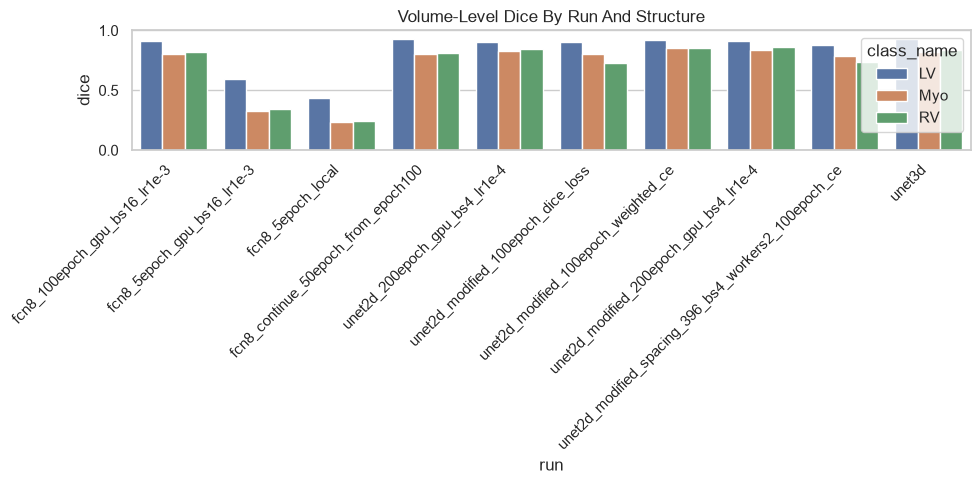

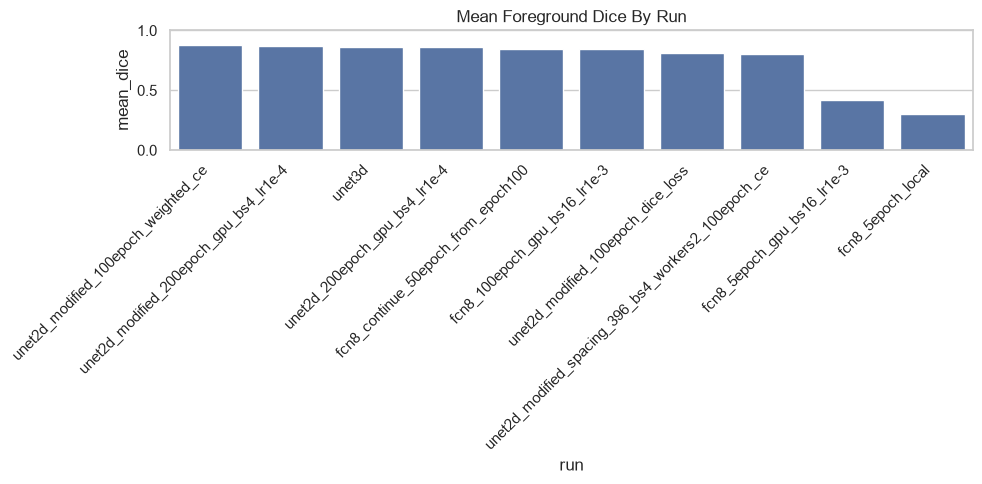

In [8]:
if all_metrics.empty:
    print("No evaluation metrics available for comparison.")
else:
    by_run_class = all_metrics.groupby(["run", "paper_model", "class_name"], as_index=False).agg(
        dice=("dice", "mean"),
        assd_mm=("assd_mm", "mean"),
        hd_mm=("hd_mm", "mean"),
        volumes=("volume_id", "nunique"),
    )
    display(by_run_class.sort_values(["run", "class_name"]))

    phase_metrics = all_metrics[all_metrics["phase"].isin(["ED", "ES"])]
    by_run_phase = phase_metrics.groupby(["run", "paper_model", "phase"], as_index=False).agg(
        mean_dice=("dice", "mean"),
        mean_assd_mm=("assd_mm", "mean"),
        mean_hd_mm=("hd_mm", "mean"),
        volumes=("volume_id", "nunique"),
        class_rows=("dice", "size"),
    )
    by_run_phase_class = phase_metrics.groupby(["run", "paper_model", "phase", "class_name"], as_index=False).agg(
        dice=("dice", "mean"),
        assd_mm=("assd_mm", "mean"),
        hd_mm=("hd_mm", "mean"),
        volumes=("volume_id", "nunique"),
    )

    print("Mean foreground metrics by run and cardiac phase:")
    display(by_run_phase.sort_values(["run", "phase"]).style.format({
        "mean_dice": "{:.3f}",
        "mean_assd_mm": "{:.2f}",
        "mean_hd_mm": "{:.2f}",
    }))

    print("Metrics by run, cardiac phase, and structure:")
    display(by_run_phase_class.sort_values(["run", "phase", "class_name"]).style.format({
        "dice": "{:.3f}",
        "assd_mm": "{:.2f}",
        "hd_mm": "{:.2f}",
    }))

    plt.figure(figsize=(max(10, 0.7 * by_run_class["run"].nunique()), 5))
    sns.barplot(data=by_run_class, x="run", y="dice", hue="class_name")
    plt.xticks(rotation=45, ha="right")
    plt.ylim(0, 1)
    plt.title("Volume-Level Dice By Run And Structure")
    plt.tight_layout()

    if not by_run_phase.empty:
        plt.figure(figsize=(max(10, 0.7 * by_run_phase["run"].nunique()), 5))
        sns.barplot(data=by_run_phase, x="run", y="mean_dice", hue="phase", hue_order=["ED", "ES"])
        plt.xticks(rotation=45, ha="right")
        plt.ylim(0, 1)
        plt.title("Mean Foreground Dice By Run And Cardiac Phase")
        plt.tight_layout()

    if not run_summary.empty:
        plt.figure(figsize=(max(10, 0.7 * len(run_summary)), 5))
        order = run_summary.sort_values("mean_dice", ascending=False)["run"]
        sns.barplot(data=run_summary, x="run", y="mean_dice", order=order)
        plt.xticks(rotation=45, ha="right")
        plt.ylim(0, 1)
        plt.title("Mean Foreground Dice By Run")
        plt.tight_layout()


## Compare With Paper Results

,run,paper_model,class_name,local_dice,local_assd_mm,local_hd_mm,paper_phase_avg_dice,paper_ed_dice,delta_vs_paper_phase_avg
12,unet2d_200epoch_gpu_bs4_lr1e-4,2D U-Net,LV,0.903,1.10,11.21,0.951,0.965000,-0.048
13,unet2d_200epoch_gpu_bs4_lr1e-4,2D U-Net,Myo,0.832,1.00,21.00,0.895,0.885000,-0.063
14,unet2d_200epoch_gpu_bs4_lr1e-4,2D U-Net,RV,0.844,1.69,19.81,0.887,0.936000,-0.043
15,unet2d_modified_100epoch_dice_loss,2D U-Net (mod.),LV,0.907,0.70,19.84,0.951,0.966000,-0.044
16,unet2d_modified_100epoch_dice_loss,2D U-Net (mod.),Myo,0.807,0.98,40.16,0.899,0.892000,-0.092
17,unet2d_modified_100epoch_dice_loss,2D U-Net (mod.),RV,0.731,1.89,29.76,0.893,0.934000,-0.162
18,unet2d_modified_100epoch_weighted_ce,2D U-Net (mod.),LV,0.922,0.42,7.77,0.951,0.966000,-0.029
19,unet2d_modified_100epoch_weighted_ce,2D U-Net (mod.),Myo,0.850,0.63,14.13,0.899,0.892000,-0.049
20,unet2d_modified_100epoch_weighted_ce,2D U-Net (mod.),RV,0.857,1.42,17.69,0.893,0.934000,-0.036
21,unet2d_modified_200epoch_gpu_bs4_lr1e-4,2D U-Net (mod.),LV,0.909,0.80,7.61,0.951,0.966000,-0.042


,run,paper_model,mean_dice,paper_mean_fg_dice,delta_vs_paper_mean_fg,mean_assd_mm,mean_hd_mm
6,unet2d_modified_100epoch_weighted_ce,2D U-Net (mod.),0.876,0.914,-0.038,0.83,13.19
7,unet2d_modified_200epoch_gpu_bs4_lr1e-4,2D U-Net (mod.),0.870,0.914,-0.044,0.92,15.57
9,unet3d,3D U-Net (mod.),0.862,0.859,+0.003,0.49,11.05
4,unet2d_200epoch_gpu_bs4_lr1e-4,2D U-Net,0.860,0.911,-0.051,1.26,17.34
3,fcn8_continue_50epoch_from_epoch100,FCN-8,0.848,0.902,-0.054,0.76,15.31
0,fcn8_100epoch_gpu_bs16_lr1e-3,FCN-8,0.845,0.902,-0.057,0.68,13.02
5,unet2d_modified_100epoch_dice_loss,2D U-Net (mod.),0.815,0.914,-0.099,1.19,29.92
8,unet2d_modified_spacing_396_bs4_workers2_100epoch_ce,2D U-Net (mod.),0.801,0.914,-0.113,2.73,40.55
1,fcn8_5epoch_gpu_bs16_lr1e-3,FCN-8,0.422,0.902,-0.480,4.39,30.39
2,fcn8_5epoch_local,FCN-8,0.306,0.902,-0.596,6.00,45.79


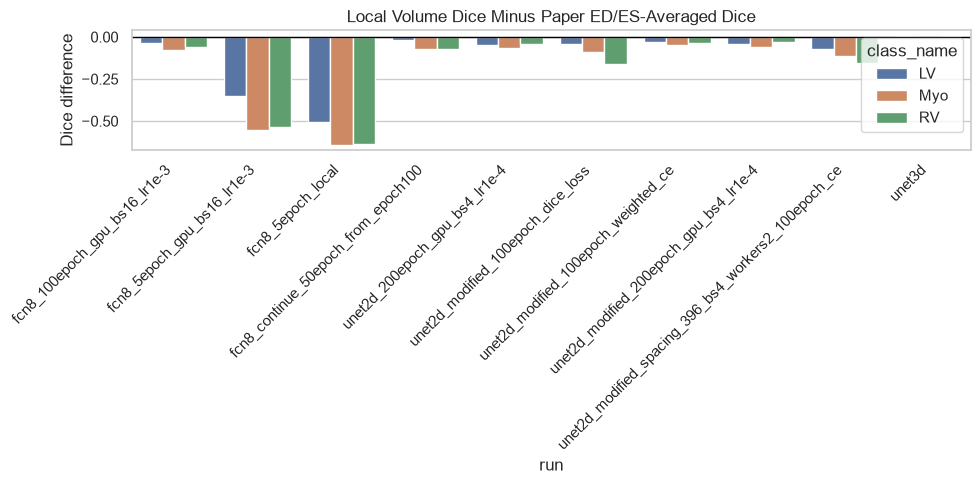

In [9]:
if all_metrics.empty:
    print("No evaluation metrics available for paper comparison.")
else:
    phase_metrics = all_metrics[all_metrics["phase"].isin(["ED", "ES"])]
    by_run_phase_class = phase_metrics.groupby(["run", "paper_model", "class_name", "phase"], as_index=False).agg(
        local_dice=("dice", "mean"),
        local_assd_mm=("assd_mm", "mean"),
        local_hd_mm=("hd_mm", "mean"),
        volumes=("volume_id", "nunique"),
    )
    phase_comparison = by_run_phase_class.merge(paper_phase, on=["paper_model", "class_name", "phase"], how="left")
    phase_comparison["delta_vs_paper_phase"] = phase_comparison["local_dice"] - phase_comparison["paper_dice"]

    print("Local ED/ES Dice compared with paper ED/ES Dice:")
    display(phase_comparison.sort_values(["paper_model", "run", "phase", "class_name"]).style.format({
        "local_dice": "{:.3f}",
        "paper_dice": "{:.3f}",
        "delta_vs_paper_phase": "{:+.3f}",
        "local_assd_mm": "{:.2f}",
        "local_hd_mm": "{:.2f}",
    }))

    plot_data = phase_comparison.dropna(subset=["paper_dice"])
    if not plot_data.empty:
        g = sns.catplot(
            data=plot_data,
            x="run",
            y="delta_vs_paper_phase",
            hue="class_name",
            col="phase",
            kind="bar",
            height=5,
            aspect=max(1.2, 0.35 * plot_data["run"].nunique()),
            col_order=["ED", "ES"],
        )
        for ax in g.axes.flat:
            ax.axhline(0, color="black", linewidth=1)
            ax.tick_params(axis="x", rotation=45)
        g.set_axis_labels("Run", "Dice difference")
        g.set_titles("{col_name}")
        g.fig.suptitle("Local Volume Dice Minus Paper Dice By Cardiac Phase", y=1.05)

    by_run_class = all_metrics.groupby(["run", "paper_model", "class_name"], as_index=False).agg(
        local_dice=("dice", "mean"),
        local_assd_mm=("assd_mm", "mean"),
        local_hd_mm=("hd_mm", "mean"),
    )
    comparison = by_run_class.merge(paper_by_class, on=["paper_model", "class_name"], how="left")
    comparison["delta_vs_paper_phase_avg"] = comparison["local_dice"] - comparison["paper_phase_avg_dice"]
    print("Local Dice compared with paper ED/ES-averaged Dice:")
    display(comparison.sort_values(["paper_model", "run", "class_name"]).style.format({
        "local_dice": "{:.3f}",
        "paper_phase_avg_dice": "{:.3f}",
        "paper_ed_dice": "{:.3f}",
        "paper_es_dice": "{:.3f}",
        "delta_vs_paper_phase_avg": "{:+.3f}",
        "local_assd_mm": "{:.2f}",
        "local_hd_mm": "{:.2f}",
    }))

    model_summary = run_summary.merge(paper_model_mean, on="paper_model", how="left") if not run_summary.empty else pd.DataFrame()
    if not model_summary.empty:
        model_summary["delta_vs_paper_mean_fg"] = model_summary["mean_dice"] - model_summary["paper_mean_fg_dice"]
        display(model_summary[["run", "paper_model", "mean_dice", "paper_mean_fg_dice", "delta_vs_paper_mean_fg", "mean_assd_mm", "mean_hd_mm"]].sort_values("mean_dice", ascending=False).style.format({
            "mean_dice": "{:.3f}",
            "paper_mean_fg_dice": "{:.3f}",
            "delta_vs_paper_mean_fg": "{:+.3f}",
            "mean_assd_mm": "{:.2f}",
            "mean_hd_mm": "{:.2f}",
        }))


## Skipped Or Failed Runs


In [10]:
if eval_results.empty:
    print("No evaluation attempts recorded.")
else:
    skipped_or_failed = eval_results[eval_results["status"].isin(["skipped", "failed"])]
    if skipped_or_failed.empty:
        print("No skipped or failed runs.")
    else:
        display(skipped_or_failed[["run", "status", "reason"]])


,run,status,reason
1,fcn8_150epoch_combined_from_100_plus_50,skipped,no checkpoint .pt file found


## Notes

- This notebook compares local evaluation metrics against the paper's published Dice values. Local metrics are only directly comparable if preprocessing, split, postprocessing, and evaluation space match the paper.
- The current evaluator reconstructs/evaluates in the preprocessed HDF5 space. It uses spacing metadata for ASSD and Hausdorff distance in millimetres, but it does not yet warp predictions back to the original NIfTI grid.
- Runs must have saved `.pt` checkpoints. A run folder with only `metrics.csv` and `config.json` cannot be re-evaluated.
